# Setup and Imports


In [58]:
# Run this cell first in every notebook
import os
import sys

sys.path.append(os.path.abspath('../src'))

%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np

from demodulator import (
    downconvert_to_baseband,
    estimate_baseband_bandwidth,
    load_mono_normalized_audio,
    locate_pilot_start,
    matched_filter_sync,
    slice_pilot_samples,
    downsample_from_offset
)
from modulator import map_bits_to_symbols
from plot_utils import plot_complex_parts, plot_correlation_response, plot_fft
from sync import generate_zadoff_chu_audio
import config


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# System Parameters


In [59]:
# Match these exactly to TX.
FS = config.FS
F_CARRIER = config.F_CARRIER
SYMBOL_RATE = config.SYMBOL_RATE
SAMPLES_PER_SYMBOL = config.SAMPLES_PER_SYMBOL
ZC_ROOT = config.u_zadoff_chu
ZC_LENGTH = config.len_zadoff_chu
SYNC_GAP_SECONDS = config.SYNC_GAP_SECONDS

rx_path = '../data/tx_single_carrier_test.wav'

""" rx_path = '../data/tx_single_carrier_test.wav' """

" rx_path = '../data/tx_single_carrier_test.wav' "

# Load and Downconvert Audio


In [60]:
fs, rx_audio = load_mono_normalized_audio(rx_path)
if fs != FS:
    raise ValueError(f'Expected sample rate {FS}, got {fs}')


rx_baseband = downconvert_to_baseband(
    rx_audio=rx_audio,
    fs=FS,
    carrier_freq=F_CARRIER,
    cutoff_hz=SYMBOL_RATE,
    filter_order=5,
)

(<Figure size 1200x400 with 1 Axes>,
 <Axes: title={'center': 'FFT'}, xlabel='Frequency [Hz]', ylabel='Magnitude'>)

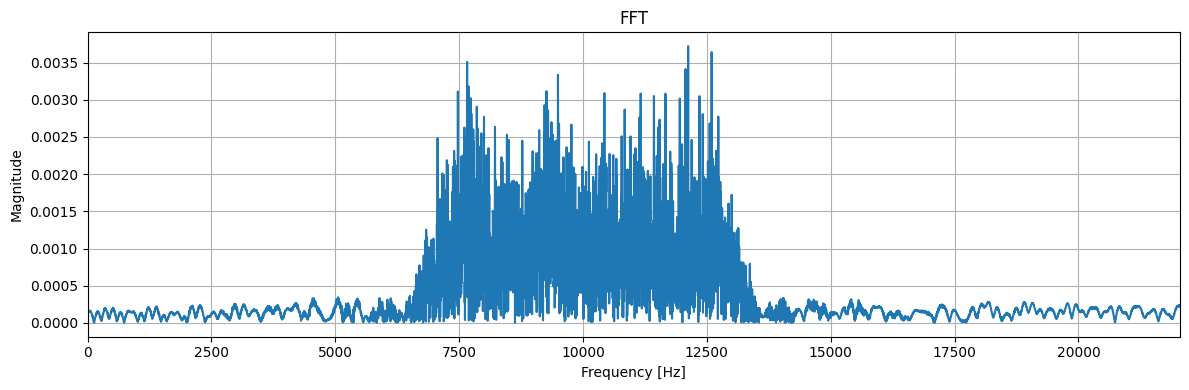

In [61]:
plot_fft(rx_audio,fs)

(<Figure size 1200x400 with 1 Axes>,
 <Axes: title={'center': 'FFT'}, xlabel='Frequency [Hz]', ylabel='Magnitude'>)

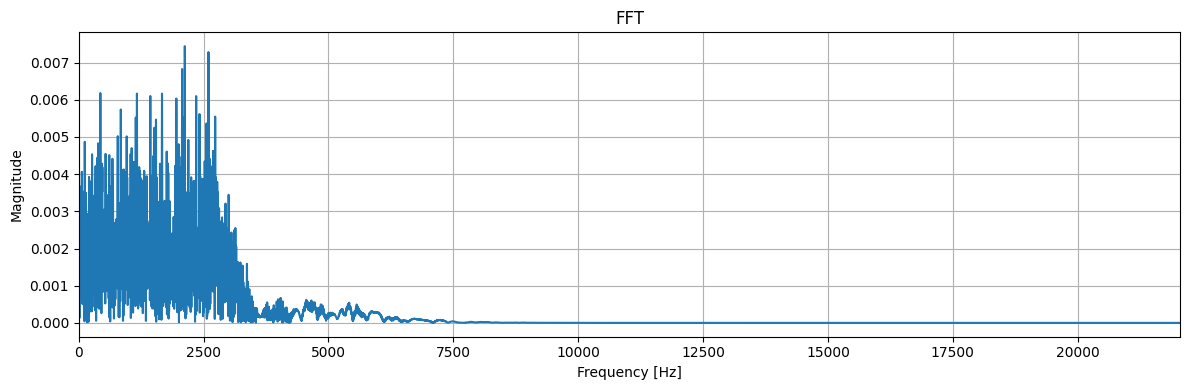

In [62]:
plot_fft(rx_baseband,FS)

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Real Part of Signal'}, xlabel='Sample Index', ylabel='Amplitude'>,
        <Axes: title={'center': 'Imaginary Part of Signal'}, xlabel='Sample Index', ylabel='Amplitude'>],
       dtype=object))

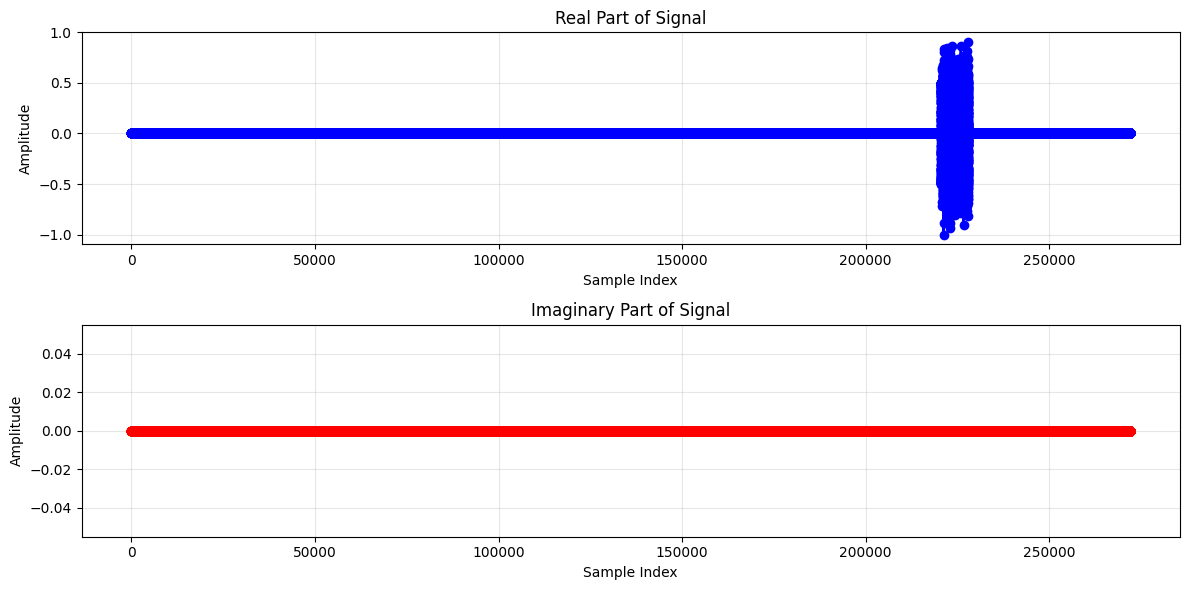

In [63]:
plot_complex_parts(rx_audio)

In [64]:
reference_zc = generate_zadoff_chu_audio(ZC_LENGTH, ZC_ROOT)
zc_start_idx, corr = matched_filter_sync(rx_baseband, reference_zc)

pilot_start_idx = locate_pilot_start(
    sync_start_idx=zc_start_idx,
    sync_length=ZC_LENGTH,
    fs=FS,
    gap_seconds=SYNC_GAP_SECONDS,
)

print('-' * 50)
print(f'Zadoff-Chu peak found at sample index: {zc_start_idx}')
print(f'Known pilots begin at sample index: {pilot_start_idx}')
print('-' * 50)


--------------------------------------------------
Zadoff-Chu peak found at sample index: 220500
Known pilots begin at sample index: 220853
--------------------------------------------------


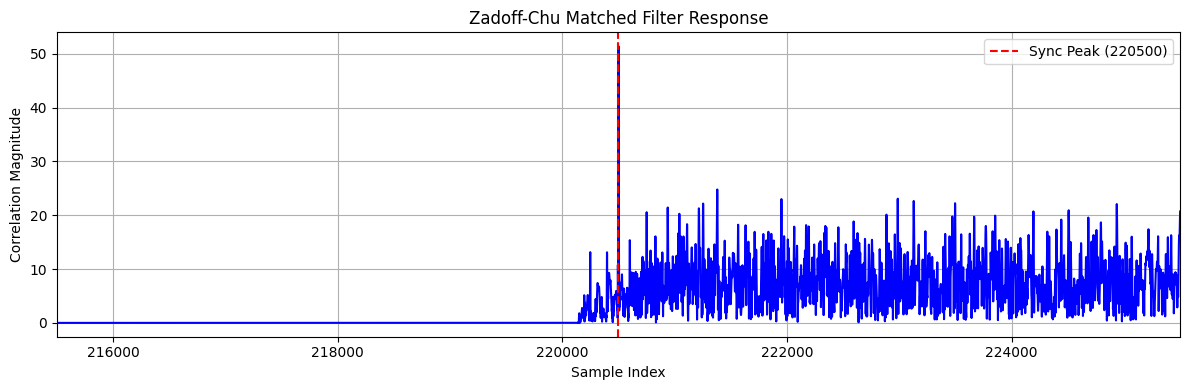

In [65]:
plot_correlation_response(corr, zc_start_idx)
plt.show()


# Pilot Extraction


In [66]:
pilot_bits = config.pilot_bits
pilot_symbols = map_bits_to_symbols(pilot_bits, config.M, METHOD=config.modulation_method)
KNOWN_PILOT_SYMBOLS = pilot_symbols

rx_pilots = slice_pilot_samples(
    rx_baseband=rx_baseband,
    pilot_start_idx=pilot_start_idx,
    num_pilot_symbols=len(KNOWN_PILOT_SYMBOLS),
    samples_per_symbol=SAMPLES_PER_SYMBOL,
)


(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Real Part of Signal'}, xlabel='Sample Index', ylabel='Amplitude'>,
        <Axes: title={'center': 'Imaginary Part of Signal'}, xlabel='Sample Index', ylabel='Amplitude'>],
       dtype=object))

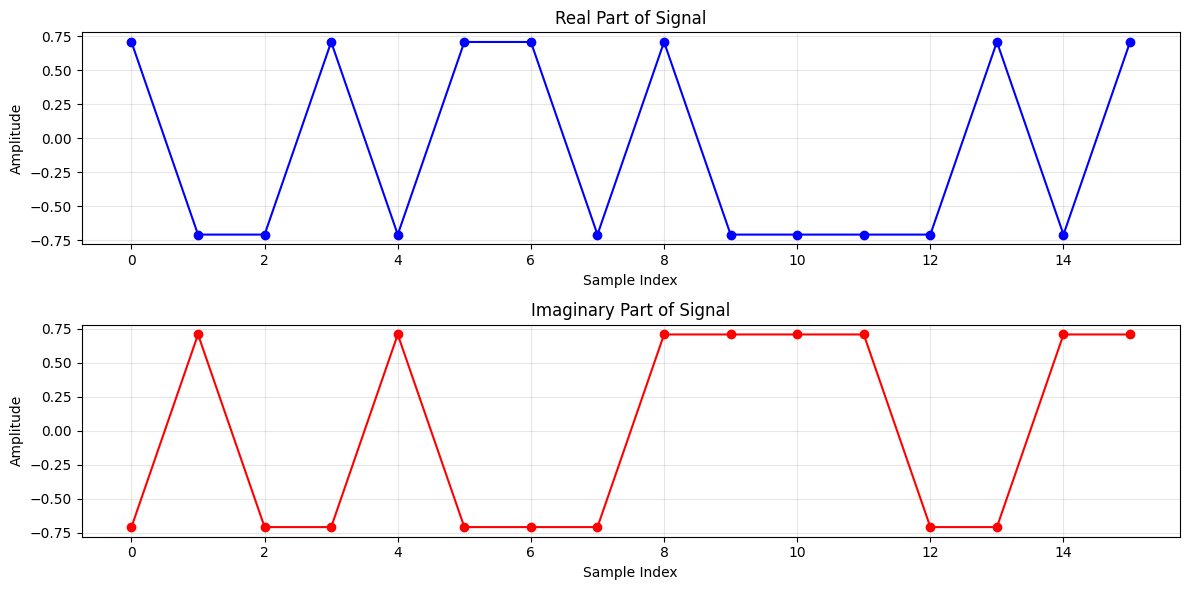

In [67]:
plot_complex_parts(pilot_symbols)

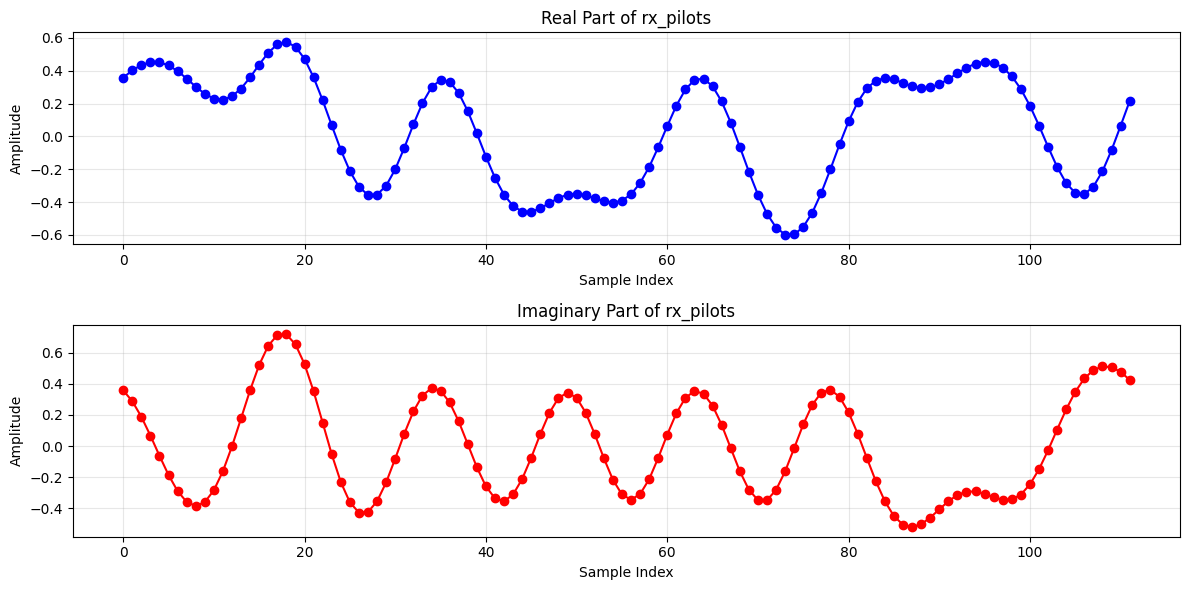

In [68]:
plot_complex_parts(rx_pilots[config.SPAN*SAMPLES_PER_SYMBOL:config.SPAN*SAMPLES_PER_SYMBOL+120], title_prefix='rx_pilots')
plt.show()

### Synchronization 

Best offset inside pilot slice: 0


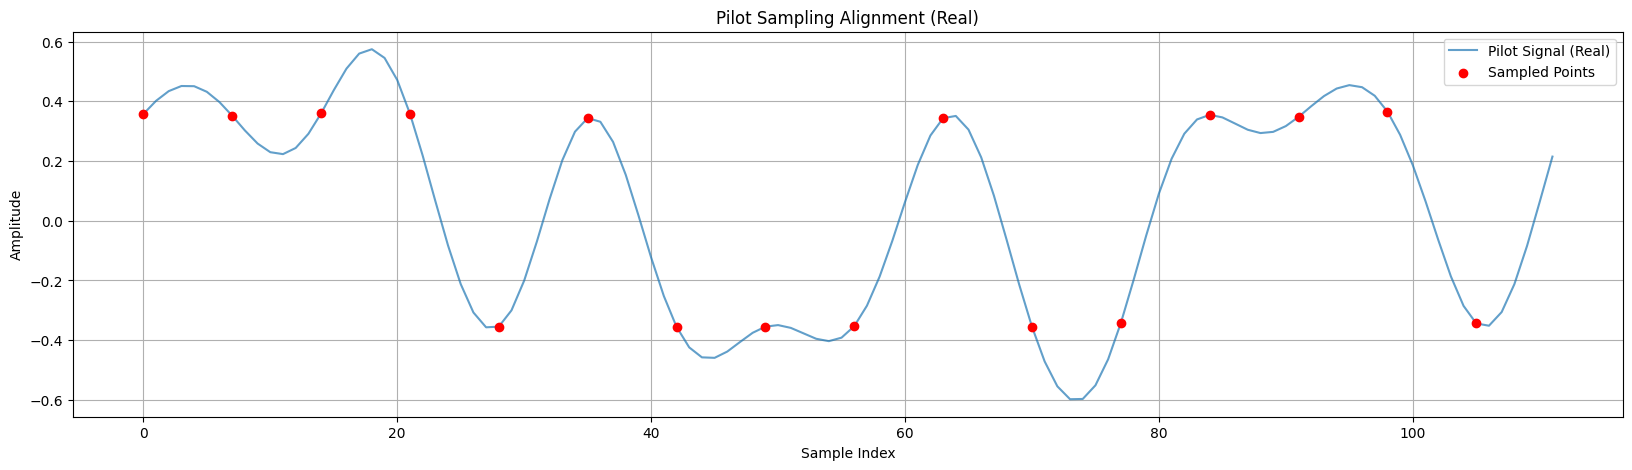

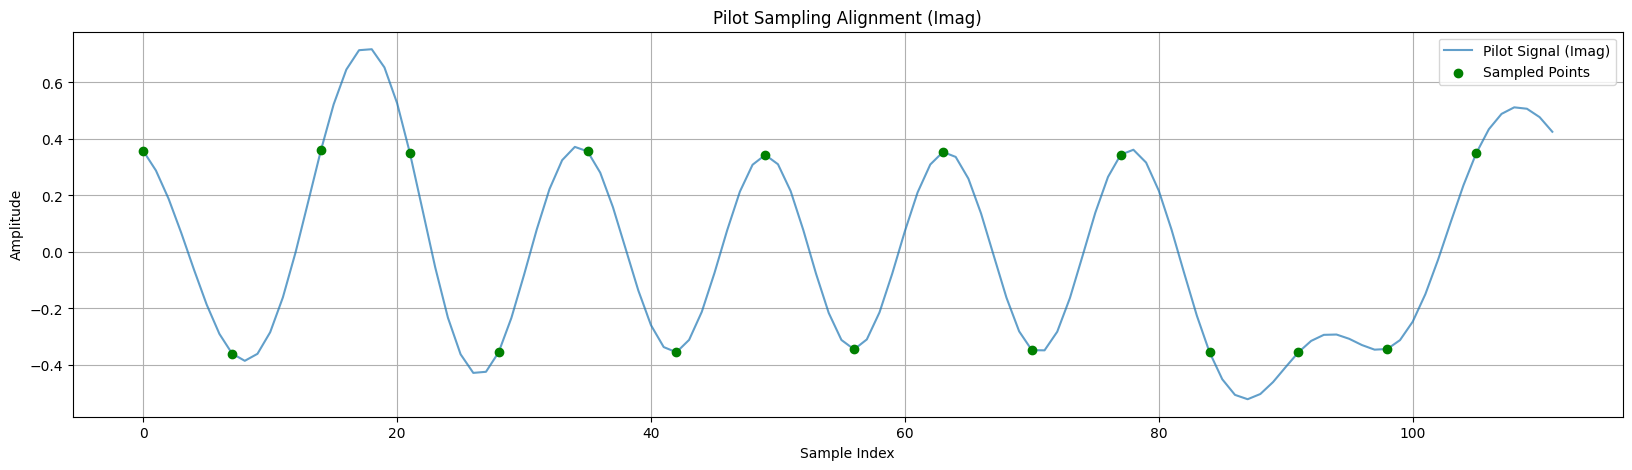


Known pilot symbols:
[ 0.70710678-0.70710678j -0.70710678+0.70710678j -0.70710678-0.70710678j
  0.70710678-0.70710678j -0.70710678+0.70710678j  0.70710678-0.70710678j
  0.70710678-0.70710678j -0.70710678-0.70710678j  0.70710678+0.70710678j
 -0.70710678+0.70710678j -0.70710678+0.70710678j -0.70710678+0.70710678j
 -0.70710678-0.70710678j  0.70710678-0.70710678j -0.70710678+0.70710678j
  0.70710678+0.70710678j]

Recovered pilot samples:
[ 0.35742373+0.35784015j  0.35168381-0.35954179j  0.35946772+0.36016173j
  0.35879237+0.35138925j -0.35478613-0.35471078j  0.34394057+0.35602023j
 -0.3552656 -0.35501335j -0.35490722+0.34356902j -0.35324168-0.3447382j
  0.34377308+0.35389332j -0.35496693-0.34753156j -0.34273333+0.34415344j
  0.354745  -0.35498765j  0.34797899-0.35492966j  0.36593687-0.34331018j
 -0.34406375+0.3486609j ]


In [69]:
L = SAMPLES_PER_SYMBOL
KNOWN = KNOWN_PILOT_SYMBOLS

# ================================
# REMOVE SINC DELAY REGION
# ================================
rxp = rx_pilots[config.SPAN * L:]

NUM_PILOTS = len(KNOWN)

# ================================
# FIND BEST OFFSET
# ================================
best_offset = 0
best_metric = -np.inf

for offset in range(L):
    samples = rxp[offset::L][:NUM_PILOTS]
    
    metric = np.abs(np.sum(samples * np.conj(KNOWN)))
    
    if metric > best_metric:
        best_metric = metric
        best_offset = offset

print(f"Best offset inside pilot slice: {best_offset}")

# ================================
# GET FINAL SAMPLE INDICES
# ================================
sample_indices = np.arange(best_offset, best_offset + NUM_PILOTS*L, L)

# ================================
# PLOT REAL PART
# ================================
import matplotlib.pyplot as plt

plt.figure(figsize=(20,5))

plt.plot(np.real(rxp), label="Pilot Signal (Real)", alpha=0.7)

plt.scatter(sample_indices,
            np.real(rxp[sample_indices]),
            color='red',
            label="Sampled Points",
            zorder=5)

plt.title("Pilot Sampling Alignment (Real)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.show()

# ================================
# PLOT IMAG PART
# ================================
plt.figure(figsize=(20,5))

plt.plot(np.imag(rxp), label="Pilot Signal (Imag)", alpha=0.7)

plt.scatter(sample_indices,
            np.imag(rxp[sample_indices]),
            color='green',
            label="Sampled Points",
            zorder=5)

plt.title("Pilot Sampling Alignment (Imag)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.show()

# ================================
# VERIFY SYMBOLS
# ================================
rx_samples = rxp[best_offset::L][:NUM_PILOTS]

print("\nKnown pilot symbols:")
print(KNOWN)

print("\nRecovered pilot samples:")
print(rx_samples)

In [70]:
start = pilot_start_idx + config.SPAN * L + best_offset

downsampled_symbols, ds_signal = downsample_from_offset(
    rx_baseband,
    start,
    L
)

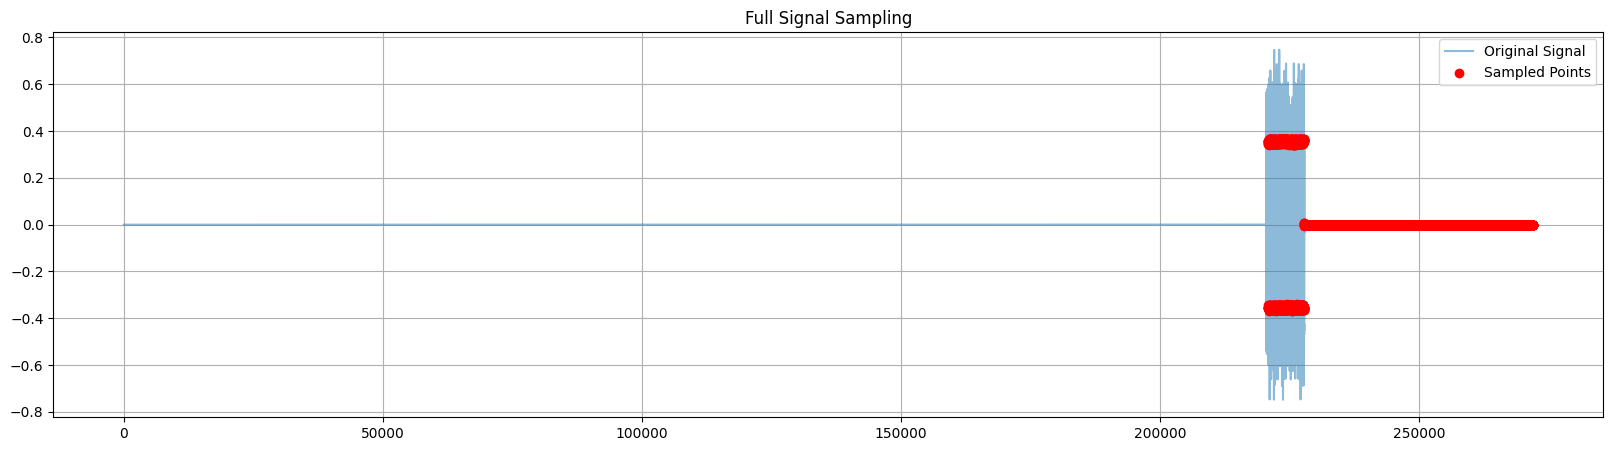

In [71]:
plt.figure(figsize=(20,5))

plt.plot(np.real(rx_baseband), label="Original Signal", alpha=0.5)

sample_indices = np.arange(start, len(rx_baseband), L)

plt.scatter(sample_indices,
            np.real(rx_baseband[sample_indices]),
            color='red',
            label="Sampled Points",
            zorder=5)

plt.title("Full Signal Sampling")
plt.grid(True)
plt.legend()
plt.show()

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Real Part of Signal'}, xlabel='Sample Index', ylabel='Amplitude'>,
        <Axes: title={'center': 'Imaginary Part of Signal'}, xlabel='Sample Index', ylabel='Amplitude'>],
       dtype=object))

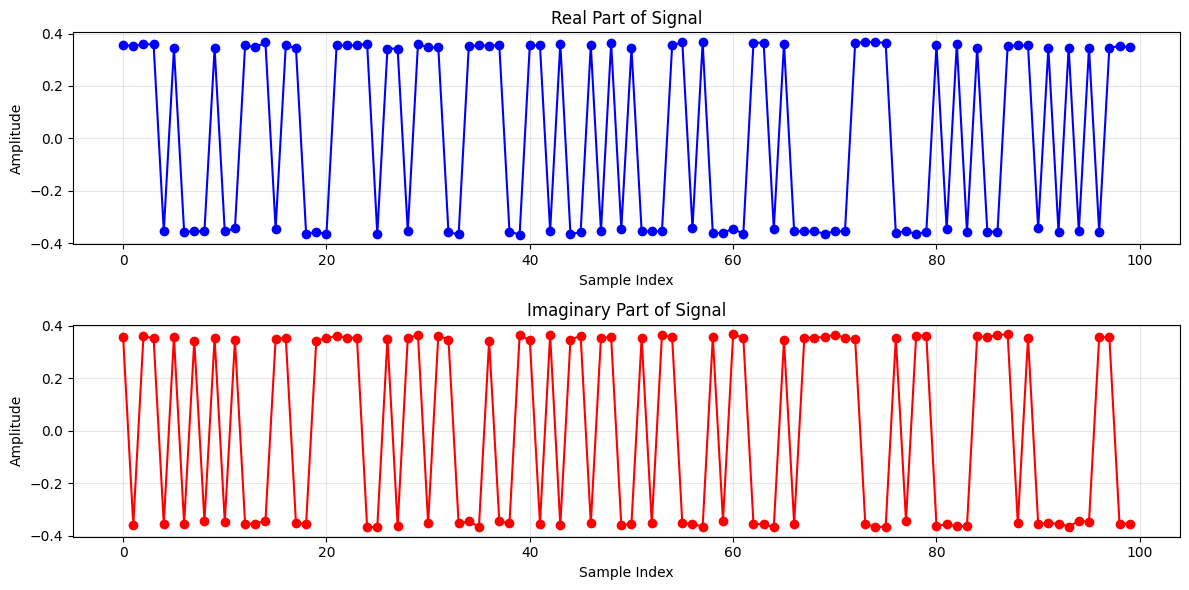

In [72]:
plot_complex_parts(rx_baseband[sample_indices][0:100])

In [73]:
def symbols_to_bits(symbols, M=4, METHOD="QAM"):
    
    if METHOD == "QAM":
        symbols = np.asarray(symbols)
        
        k = int(np.log2(M))
        k_half = k // 2
        L = int(np.sqrt(M))
        
        # Same normalization used in TX
        norm_factor = np.sqrt((2 / 3) * (M - 1))
        
        # Denormalize
        symbols = symbols * norm_factor
        
        bits_out = []
        
        for s in symbols:
            i_val = np.real(s)
            q_val = np.imag(s)
            
            # Find nearest level index
            i_idx = int(np.round((i_val + (L - 1)) / 2))
            q_idx = int(np.round((q_val + (L - 1)) / 2))
            
            # Clip (important for noise robustness)
            i_idx = np.clip(i_idx, 0, L - 1)
            q_idx = np.clip(q_idx, 0, L - 1)
            
            # Convert to bits
            i_bits = list(map(int, format(i_idx, f'0{k_half}b')))
            q_bits = list(map(int, format(q_idx, f'0{k_half}b')))
            
            bits_out.extend(i_bits + q_bits)
        
        return np.array(bits_out)

In [74]:
recovered_bits = symbols_to_bits(
    downsampled_symbols,
    M=config.M,
    METHOD=config.modulation_method
)

In [75]:
input_path = "../data/message.txt"
with open(input_path, "r") as f:
        data_binary = f.read().strip()


# Calculate Bit Error Rate (BER)
recovered_bit_string = ''.join(map(str, recovered_bits))

# Determine the length to compare (use the shorter length or match as needed)
min_length = min(len(recovered_bit_string), len(data_binary))

# Compare bits
bit_errors = sum(r != d for r, d in zip(recovered_bit_string[:min_length], data_binary[:min_length]))

# Calculate BER
ber = bit_errors / min_length if min_length > 0 else 0

print(f"Recovered bits: {recovered_bit_string[:min_length]}")
print(f"Original bits:  {data_binary[:min_length]}")
print(f"\nTotal bits compared: {min_length}")
print(f"Bit errors: {bit_errors}")
print(f"Bit Error Rate (BER): {ber:.6f} ({ber*100:.2f}%)")

Recovered bits: 111011110011000100110001101010011110000101111111100011100111101101001010111000011110011001011001110010010001111000100100010110100011000101010101111010100100010110001000110101111011001000100010011110101111111100101101010101001110111010001100010100110001001011111000110011111110010010110100101000011110110100110100110100011001110101100110011110011100000100101100100001100101111110100001100010001000100100101010111010100001100000000110110111001101011110000110101100001110010111100101100011100010100011101111110010001000110001111111010011001010000110110110001011110000111001000000000010110000001001000101100011110010001111001000000110010110110110001000010001001110000100011101111110110000000011010101101110001101111010011101001110011111100110000101001010001110000100011001110000110000000100010011101110000110110100011100011001110000100011010000101000010010111111011100010100110110111000000010010001011010110100110111100001000000011111101000000001010011100101101110100010000011101111010010

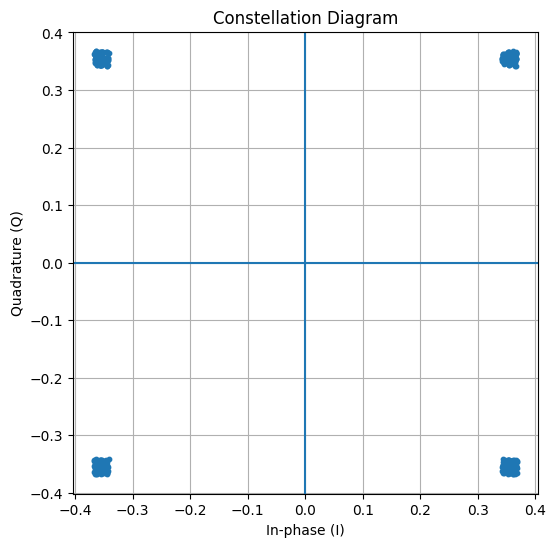

In [76]:
plt.figure(figsize=(6,6))

no_of_symbols_to_plot = 500
downsampled_symbols = downsampled_symbols[: no_of_symbols_to_plot]

plt.scatter(np.real(downsampled_symbols),
            np.imag(downsampled_symbols),
            s=10)

plt.axhline(0)
plt.axvline(0)

plt.title("Constellation Diagram")
plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")
plt.grid(True)
plt.axis('equal')

plt.show()